# Transformações Geométricas com Matplotlib
Resolução dos exercícios 1 a 10: translação, escala, rotação, reflexão, cisalhamento e composição de transformações.

## Setup
Nesta seção instalamos e importamos as bibliotecas e definimos as funções usadas em todos os exercícios.

- **NumPy**: guarda os pontos em arrays e faz as operações com matrizes.
- **Matplotlib**: plota as figuras antes e depois de cada transformação.

Cada ponto ocupa uma linha do array (`[[x1, y1], [x2, y2], ...]`). Assim, as mesmas funções servem para um ponto isolado e para um polígono.

In [1]:
#Instalação

%pip install matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Imports

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

In [5]:
#Funções de transformação

def translate(points, vector):
    return points + np.array(vector)

def scale(points, sx, sy=None):
    sy = sx if sy is None else sy
    M = np.array([[sx, 0],
                  [0, sy]])
    return points @ M.T

def rotate(points, degrees):
    """Ângulo positivo = anti-horário | negativo = horário."""
    t = np.radians(degrees)
    M = np.array([[np.cos(t), -np.sin(t)],
                  [np.sin(t),  np.cos(t)]])
    return points @ M.T

def reflect(points, axis):
    M = np.array([[1, 0], [0, -1]]) if axis == "x" else np.array([[-1, 0], [0, 1]])
    return points @ M.T

def shear_x(points, k):
    M = np.array([[1, k],
                  [0, 1]])
    return points @ M.T

In [6]:
#Funções de exibição e plot

def show(names, points):
    for n, (x, y) in zip(names, np.round(points, 3) + 0.0):
        print(f"  {n}' = ({x:g}, {y:g})")

def plot_shapes(shapes, title):
    """shapes: lista de tuplas (pontos, rótulo)."""
    styles = ["-", "--", "-.", ":"]
    fig, ax = plt.subplots(figsize=(6, 6))
    for i, (pts, label) in enumerate(shapes):
        pts = np.atleast_2d(pts)
        if len(pts) == 1:
            ax.scatter(pts[:, 0], pts[:, 1], s=80, label=label, zorder=3)
            x, y = np.round(pts[0], 3) + 0.0
            ax.annotate(f"({x:g}, {y:g})", (x, y), textcoords="offset points", xytext=(6, 6))
        else:
            closed = np.vstack([pts, pts[0]])
            ax.plot(closed[:, 0], closed[:, 1], linestyle=styles[i % 4], marker="o", label=label)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.4)
    ax.legend()
    ax.set_title(title)
    plt.show()

## Exercícios
Cada exercício segue o mesmo fluxo: definir os pontos, aplicar a transformação, imprimir as novas coordenadas e plotar o original junto do transformado.

Matrizes utilizadas (θ positivo = anti-horário):

| Transformação | Matriz / Operação |
|---|---|
| Translação | $P' = P + (t_x, t_y)$ |
| Escala | $\begin{bmatrix} s_x & 0 \\ 0 & s_y \end{bmatrix}$ |
| Rotação | $\begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$ |
| Reflexão no eixo x | $\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$ |
| Reflexão no eixo y | $\begin{bmatrix} -1 & 0 \\ 0 & 1 \end{bmatrix}$ |
| Cisalhamento horizontal | $\begin{bmatrix} 1 & k \\ 0 & 1 \end{bmatrix}$ |

Nas composições (Ex. 9 e 10), as transformações são aplicadas na ordem do enunciado, e o resultado de uma é a entrada da seguinte.

Exercício 1 — Translação
  P' = (6, 1)


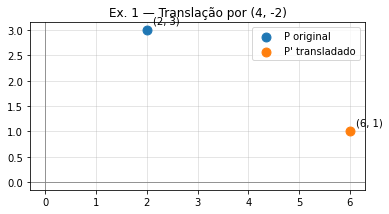

In [7]:
#Exercício 1

P = np.array([[2, 3]])
P1 = translate(P, [4, -2])

print("Exercício 1 — Translação")
show(["P"], P1)
plot_shapes([(P, "P original"), (P1, "P' transladado")], "Ex. 1 — Translação por (4, -2)")

**Resposta:** P' = (6, 1). As duas coordenadas foram alteradas: x aumentou 4 e y diminuiu 2.

Exercício 2 — Escala uniforme (fator 2)
  A' = (2, 2)
  B' = (6, 2)
  C' = (4, 8)
Área original: 3 | Área final: 12


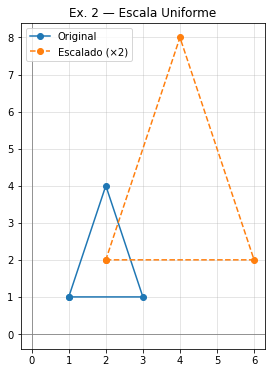

In [9]:
#Exercicio 2

triangle = np.array([[1, 1], [3, 1], [2, 4]])
tri_scaled = scale(triangle, 2)

print("Exercício 2 — Escala uniforme (fator 2)")
show(["A", "B", "C"], tri_scaled)

area = lambda p: 0.5 * abs(np.cross(p[1] - p[0], p[2] - p[0]))
print(f"Área original: {area(triangle):g} | Área final: {area(tri_scaled):g}")

plot_shapes([(triangle, "Original"), (tri_scaled, "Escalado (×2)")], "Ex. 2 — Escala Uniforme")

**Resposta:** A' = (2, 2), B' = (6, 2), C' = (4, 8). Os lados dobram de tamanho e a área fica 4 vezes maior (3 → 12). Como a escala é feita em relação à origem, o triângulo também se afasta dela.

Exercício 3 — Escala não uniforme (sx=2, sy=0.5)
  A' = (2, 0.5)
  B' = (6, 0.5)
  C' = (4, 2)


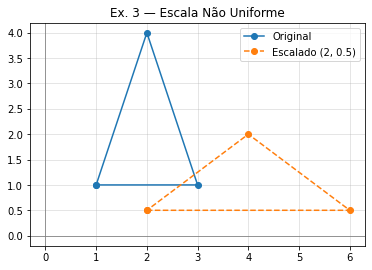

In [10]:
#Exercicio 3

tri_nonuni = scale(triangle, 2, 0.5)

print("Exercício 3 — Escala não uniforme (sx=2, sy=0.5)")
show(["A", "B", "C"], tri_nonuni)
plot_shapes([(triangle, "Original"), (tri_nonuni, "Escalado (2, 0.5)")], "Ex. 3 — Escala Não Uniforme")

**Resposta:** A' = (2, 0.5), B' = (6, 0.5), C' = (4, 2). O triângulo foi esticado na horizontal e achatado na vertical.

Exercício 4 — Rotação 90° anti-horário
  P' = (0, 1)


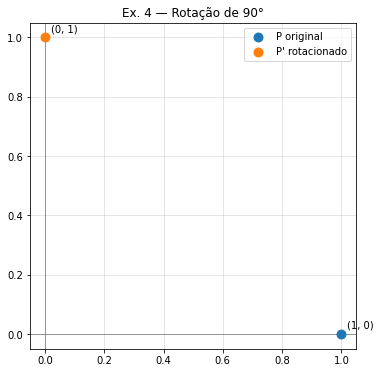

In [11]:
#Exercicio 4

P = np.array([[1, 0]])
P1 = rotate(P, 90)

print("Exercício 4 — Rotação 90° anti-horário")
show(["P"], P1)
plot_shapes([(P, "P original"), (P1, "P' rotacionado")], "Ex. 4 — Rotação de 90°")

**Resposta:** P' = (0, 1). O ponto saiu do eixo x positivo e foi para o eixo y positivo.

In [ ]:
#Exercicio 5

square = np.array([[1, 1], [1, 4], [4, 4], [4, 1]])
sq_rot = rotate(square, -45)  # negativo = horário

print("Exercício 5 — Rotação 45° horário")
show(["A", "B", "C", "D"], sq_rot)
plot_shapes([(square, "Original"), (sq_rot, "Rotacionado (-45°)")], "Ex. 5 — Rotação de um Quadrado")

**Resposta:** A' ≈ (1.414, 0), B' ≈ (3.536, 2.121), C' ≈ (5.657, 0), D' ≈ (3.536, -2.121).
Para a rotação horária usamos θ = -45° na matriz de rotação padrão.

Exercício 6 — Reflexão no eixo y
  P' = (-2, 5)


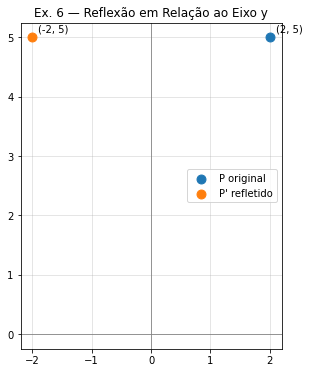

In [13]:
#Exercicio 6

P = np.array([[2, 5]])
P1 = reflect(P, "y")

print("Exercício 6 — Reflexão no eixo y")
show(["P"], P1)
plot_shapes([(P, "P original"), (P1, "P' refletido")], "Ex. 6 — Reflexão em Relação ao Eixo y")

**Resposta:** P' = (-2, 5). Somente o sinal de x foi invertido.

Exercício 7 — Reflexão no eixo x
  A' = (2, -3)
  B' = (4, -3)
  C' = (3, -5)


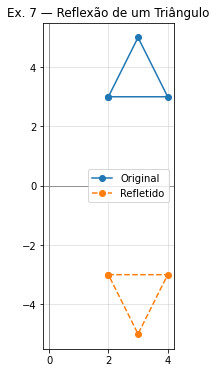

In [14]:
#Execicio 7

tri7 = np.array([[2, 3], [4, 3], [3, 5]])
tri7_ref = reflect(tri7, "x")

print("Exercício 7 — Reflexão no eixo x")
show(["A", "B", "C"], tri7_ref)
plot_shapes([(tri7, "Original"), (tri7_ref, "Refletido")], "Ex. 7 — Reflexão de um Triângulo")

**Resposta:** A' = (2, -3), B' = (4, -3), C' = (3, -5). O sinal de y foi invertido e o triângulo ficou espelhado abaixo do eixo x.

In [15]:
#Exercicio 8

P = np.array([[2, 3]])
P1 = shear_x(P, 2)

print("Exercício 8 — Cisalhamento horizontal (k=2)")
show(["P"], P1)
plot_shapes([(P, "P original"), (P1, "P' cisalhado")], "Ex. 8 — Cisalhamento Horizontal")

**Resposta:** P' = (8, 3), pois x' = x + k·y = 2 + 2·3 = 8. O valor de y não muda.

Exercício 9 — Composição
  P após translação' = (4, 1)
  P após rotação' = (-1, 4)
  P após escala' = (-2, 8)


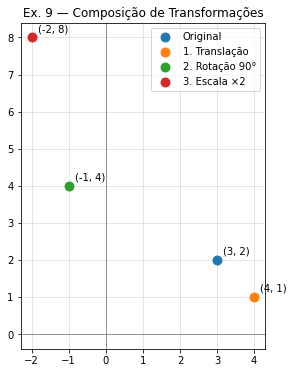

In [17]:
#Exercicio 9

P = np.array([[3, 2]])
step1 = translate(P, [1, -1])
step2 = rotate(step1, 90)
step3 = scale(step2, 2)

print("Exercício 9 — Composição")
show(["P após translação"], step1)
show(["P após rotação"], step2)
show(["P após escala"], step3)

plot_shapes([(P, "Original"), (step1, "1. Translação"),
             (step2, "2. Rotação 90°"), (step3, "3. Escala ×2")],
            "Ex. 9 — Composição de Transformações")

**Resposta:** P' = (-2, 8).
Passo a passo: (3, 2) → translação → (4, 1) → rotação 90° → (-1, 4) → escala ×2 → (-2, 8).

Após translação:
  A' = (-1, 4)
  B' = (3, 4)
  C' = (3, 6)
  D' = (-1, 6)
Após escala:
  A' = (-1.5, 2)
  B' = (4.5, 2)
  C' = (4.5, 3)
  D' = (-1.5, 3)
Após reflexão:
  A' = (1.5, 2)
  B' = (-4.5, 2)
  C' = (-4.5, 3)
  D' = (1.5, 3)


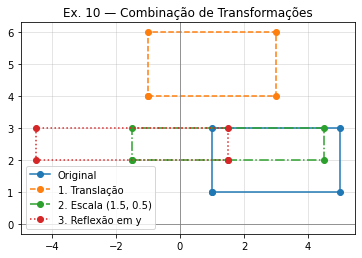

In [18]:
#Exercicio 10

rect = np.array([[1, 1], [5, 1], [5, 3], [1, 3]])
r1 = translate(rect, [-2, 3])
r2 = scale(r1, 1.5, 0.5)
r3 = reflect(r2, "y")

names = ["A", "B", "C", "D"]
print("Após translação:"); show(names, r1)
print("Após escala:");     show(names, r2)
print("Após reflexão:");   show(names, r3)

plot_shapes([(rect, "Original"), (r1, "1. Translação"),
             (r2, "2. Escala (1.5, 0.5)"), (r3, "3. Reflexão em y")],
            "Ex. 10 — Combinação de Transformações")

**Resposta:** A' = (1.5, 2), B' = (-4.5, 2), C' = (-4.5, 3), D' = (1.5, 3).
Passo a passo:
translação → A(-1, 4), B(3, 4), C(3, 6), D(-1, 6)
escala → A(-1.5, 2), B(4.5, 2), C(4.5, 3), D(-1.5, 3)
reflexão em y → resultado final acima.